In [1]:
import requests_cache
requests_cache.install_cache("cache.sqlite", backend="sqlite")
import requests # Making web requests
import pandas as pd # Tabular data operations
import geopandas as gpd # Geospatial data
import numpy as np
import folium
from dotenv import load_dotenv
load_dotenv()
import os
from tqdm.auto import tqdm
from pprint import pprint
pd.set_option("display.max_columns", None)

In [2]:
results = []
s = requests.Session()
s.headers.update({"X-API-Key": os.getenv("HEALTHPOINT_API_KEY")})
r = s.get("https://api.healthpointapi.com/baseR4/HealthcareService?branch-code=pharmacy&_count=200").json() # Max 200 per page
results.extend(r["entry"])
for page in tqdm(range(200, r["total"], 200)):
    next_url = r["link"][1]["url"]
    r = s.get(next_url).json()
    results.extend(r["entry"])

  0%|          | 0/5 [00:00<?, ?it/s]

In [3]:
locations = []
for r in tqdm(results):
    r = r["resource"]
    hours = 0
    for day in r.get("availableTime", [])[:7]:
        hours += (pd.Timedelta(day["availableEndTime"]) - pd.Timedelta(day["availableStartTime"])).seconds / 60 / 60
    location = {
        "name": r["name"],
        "openHoursPerWeek": hours,
        "ECP": False,
    }
    for e in r["extension"][0]["extension"]:
        if e["url"] == "dhb-region":
            location["dhb-region"] = e["valueString"]
        if e["url"] == "services-provided":
            for service in e["extension"]:
                if service.get("valueString") == 'Emergency contraceptive pill (ECP) | Morning after pill':
                    location["ECP"] = True
        for ee in e.get("extension", []):
            if ee["url"] == "coordinates":
                for eee in ee["extension"]:
                    if eee["url"] == "latitude":
                        location["latitude"] = float(eee["valueDecimal"])
                    if eee["url"] == "longitude":
                        location["longitude"] = float(eee["valueDecimal"])
    if "latitude" not in location or "longitude" not in location:
        print("No coordinates for", r["name"])
        continue
    locations.append(location)

df = pd.DataFrame(locations)
# These are either hospital pharmacies or inpatient services
# or other services that are not relevant to the public
df = df[~df.name.str.contains("Gisborne Hospital Pharmacy|Tauranga Hospital|Hawke's Bay Hospital Pharmacy|Inpatient|Pharmacy Services", case=False)]
display(df)
df.ECP.value_counts()

  0%|          | 0/1102 [00:00<?, ?it/s]

No coordinates for NorthWest 7 Day Pharmacy
No coordinates for Wyndham Prescription Centre
No coordinates for ZOOM Pharmacy
No coordinates for Chemist Warehouse Online – Covid Antivirals
No coordinates for PillDrop Pharmacy
No coordinates for Unichem Dennis Hanna Pharmacy
No coordinates for Bargain Chemist Archers
No coordinates for Chemist Warehouse Pukekohe - The Zone


,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude
0,Woolworths Pharmacy Belfast,71.0,True,Canterbury,-43.448285,172.629753
4,Unichem Ascot Pharmacy,54.0,True,Southern,-46.405920,168.392577
5,Wellworks Pharmacy Taranaki Street,50.5,True,Wellington,-41.293698,174.778695
6,Roskill Healthcare Pharmacy,40.5,True,Central Auckland,-36.904902,174.741449
7,Unichem Forté Pharmacy,45.0,True,Canterbury,-43.526306,172.638359
...,...,...,...,...,...,...
1089,Unichem Upper Hutt Health Pharmacy,57.0,True,Hutt,-41.121664,175.073129
1090,Unichem Miramar Pharmacy,54.5,True,Wellington,-41.316008,174.815042
1091,Whangamata Pharmacy,54.0,True,Waikato,-37.206811,175.871292
1092,Chemist Warehouse The Base,98.0,True,Waikato,-37.749467,175.234734


ECP
True     1010
False      71
Name: count, dtype: int64

In [4]:
df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',
 'CM Health': 'Counties Manukau',
 'Canterbury': 'Canterbury',
 'Central Auckland': 'Auckland',
 'Hawkes Bay': "Hawke's Bay",
 'Hutt': 'Capital, Coast and Hutt Valley',
 'Lakes': 'Lakes',
 'MidCentral': 'MidCentral',
 'Nelson Marlborough': 'Nelson Marlborough',
 'Northland': 'Northland',
 'South Canterbury': 'South Canterbury',
 'Southern': 'Southern',
 'Tairawhiti': 'Tairāwhiti',
 'Taranaki': 'Taranaki',
 'Waikato': 'Waikato',
 'Wairarapa': 'Wairarapa',
 'Waitematā DHB': 'Waitematā',
 'Wellington': 'Capital, Coast and Hutt Valley', # Note this merges Wellington and Hutt Valley
 'West Coast': 'West Coast',
 'Whanganui': 'Whanganui'
}, inplace=True)

/tmp/ipykernel_18133/3370469065.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["dhb-region"].replace({'Bay of Plenty': 'Bay of Plenty',


In [5]:
df["depot"] = df.name.str.contains("Depot", case=False).replace({True: "Depot", False: "Community"})
depot_by_DHB = df.groupby("dhb-region").depot.value_counts().unstack().fillna(0).astype(int).T
depot_by_DHB

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
depot,,,,,,,,,,,,,,,,,,,
Community,133,59,137,88,119,36,21,31,30,35,11,82,7,26,86,8,133,4,15
Depot,0,0,1,0,0,0,1,1,2,1,0,3,9,1,0,0,0,0,1


In [6]:
openHoursStats = df.groupby("dhb-region").openHoursPerWeek.describe().T
openHoursStats.index = "Open hours per week " + openHoursStats.index
openHoursStats

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Open hours per week count,133.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.508145,51.461864,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.359375,49.027778,51.090909,51.690196,23.250000,49.444444,51.360465,53.687500,58.877820,46.750000,49.062500
Open hours per week std,14.928614,11.129993,14.117210,11.569022,17.118056,11.207430,15.634856,7.307616,9.729598,12.058456,10.145980,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.000000,40.000000
Open hours per week 25%,46.000000,44.875000,45.000000,45.875000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,45.375000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,46.500000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,57.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,91.000000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,94.500000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [7]:
ECP = df.groupby(["dhb-region"]).ECP.value_counts().unstack().fillna(0).astype(int).rename(columns={True: "ECP", False: "No ECP"}).T.sort_index()
ECP

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
ECP,,,,,,,,,,,,,,,,,,,
ECP,126,56,130,83,115,32,20,31,29,33,10,78,7,25,84,8,126,4,13
No ECP,7,3,8,5,4,4,2,1,3,3,1,7,9,2,2,0,7,0,3


In [8]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP])
results

dhb-region,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,133.000000,59.000000,137.000000,88.000000,119.000000,36.000000,21.000000,31.000000,30.000000,35.000000,11.000000,82.000000,7.000000,26.000000,86.000000,8.000000,133.000000,4.000000,15.000000
Depot,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,3.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Open hours per week count,133.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.508145,51.461864,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.359375,49.027778,51.090909,51.690196,23.250000,49.444444,51.360465,53.687500,58.877820,46.750000,49.062500
Open hours per week std,14.928614,11.129993,14.117210,11.569022,17.118056,11.207430,15.634856,7.307616,9.729598,12.058456,10.145980,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.000000,40.000000
Open hours per week 25%,46.000000,44.875000,45.000000,45.875000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,45.375000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,46.500000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,57.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,91.000000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,94.500000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [9]:
df.to_csv("healthpoint_pharmacies_ECP.csv", index=False)

In [10]:
df = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.longitude, df.latitude), crs=4326)
df

,name,openHoursPerWeek,ECP,dhb-region,latitude,longitude,depot,geometry
0,Woolworths Pharmacy Belfast,71.0,True,Canterbury,-43.448285,172.629753,Community,POINT (172.62975 -43.44829)
4,Unichem Ascot Pharmacy,54.0,True,Southern,-46.405920,168.392577,Community,POINT (168.39258 -46.40592)
5,Wellworks Pharmacy Taranaki Street,50.5,True,"Capital, Coast and Hutt Valley",-41.293698,174.778695,Community,POINT (174.77869 -41.29370)
6,Roskill Healthcare Pharmacy,40.5,True,Auckland,-36.904902,174.741449,Community,POINT (174.74145 -36.90490)
7,Unichem Forté Pharmacy,45.0,True,Canterbury,-43.526306,172.638359,Community,POINT (172.63836 -43.52631)
...,...,...,...,...,...,...,...,...
1089,Unichem Upper Hutt Health Pharmacy,57.0,True,"Capital, Coast and Hutt Valley",-41.121664,175.073129,Community,POINT (175.07313 -41.12166)
1090,Unichem Miramar Pharmacy,54.5,True,"Capital, Coast and Hutt Valley",-41.316008,174.815042,Community,POINT (174.81504 -41.31601)
1091,Whangamata Pharmacy,54.0,True,Waikato,-37.206811,175.871292,Community,POINT (175.87129 -37.20681)
1092,Chemist Warehouse The Base,98.0,True,Waikato,-37.749467,175.234734,Community,POINT (175.23473 -37.74947)


In [11]:
sa2 = gpd.read_file("statistical-area-2-2023-generalised_simplified_22.3%.zip").dropna(subset="geometry")
sa2 = sa2[(sa2.SA22023__1 != "Chatham Islands") & (sa2.LAND_AREA_ > 0)].copy()
sa2

,SA22023_V1,SA22023__1,SA22023__2,LAND_AREA_,AREA_SQ_KM,Shape_Leng,geometry
0,100100,North Cape,North Cape,829.188012,829.188012,416039.151064,"MULTIPOLYGON (((1614055.808 6154067.023, 16141..."
1,100200,Rangaunu Harbour,Rangaunu Harbour,274.004295,274.004295,149089.110095,"MULTIPOLYGON (((1624166.328 6127258.658, 16243..."
3,100400,Karikari Peninsula,Karikari Peninsula,174.440751,174.440751,140149.099270,"MULTIPOLYGON (((1626838.499 6126965.133, 16270..."
4,100500,Tangonge,Tangonge,177.182117,177.182117,101466.900183,"POLYGON ((1623516.265 6119580.907, 1623492.213..."
5,100900,Rangitihi,Rangitihi,84.539982,84.539982,60636.302194,"POLYGON ((1629314.862 6117970.968, 1629371.783..."
...,...,...,...,...,...,...,...
2374,362601,Heidelberg,Heidelberg,1.308968,1.308968,5367.870180,"POLYGON ((1245892.259 4848174.153, 1245922.973..."
2375,363001,Clifton-Kew,Clifton-Kew,3.770832,3.770832,11890.253381,"POLYGON ((1243666.689 4847254.124, 1243677.447..."
2376,363100,Woodend-Greenhills,Woodend-Greenhills,173.600766,173.600766,166674.352079,"MULTIPOLYGON (((1248612.765 4823630.510, 12486..."
2378,363301,Bluff,Bluff,10.136949,10.290040,23162.004392,"POLYGON ((1244729.237 4827495.819, 1244667.973..."


In [12]:
BASE_URL = "http://osrm.auckland-cer.cloud.edu.au"

def drive(from_points, to_points):
    from_points_s = ";".join([f"{point.x},{point.y}" for point in from_points])
    from_indices = ";".join([str(i) for i in range(len(from_points))])
    to_points_s = ";".join([f"{point.x},{point.y}" for point in to_points])
    to_indices = ";".join([str(i + len(from_points)) for i in range(len(to_points))])
    result = requests.get(f"{BASE_URL}/table/v1/driving/{from_points_s};{to_points_s}?sources={from_indices}&destinations={to_indices}&annotations=duration,distance")
    return result.json()
result = drive(from_points=sa2.centroid.to_crs(epsg=4326), to_points=df[df.ECP].geometry.to_crs(epsg=4326))

In [13]:
min_indices = np.argmin(result["distances"], axis=1)
sa2["Distance to nearest ECP pharmacy"] = [result["distances"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Travel time to nearest ECP pharmacy"] = [result["durations"][i][min_indices[i]] for i in range(len(min_indices))]
sa2["Nearest pharmacy name"] = list(df[df.ECP].name.iloc[min_indices])
sa2["DHB"] = list(df[df.ECP]["dhb-region"].iloc[min_indices])

In [14]:
distance_stats = sa2.groupby("DHB")["Distance to nearest ECP pharmacy"].describe().T
distance_stats.index = "Distance to nearest ECP pharmacy " + distance_stats.index
distance_stats

DHB,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Distance to nearest ECP pharmacy count,181.000000,109.000000,279.000000,194.000000,212.000000,88.000000,69.000000,98.000000,82.000000,99.000000,41.000000,188.000000,27.000,65.000000,229.000000,26.000000,237.000000,28.000000,43.000000
Distance to nearest ECP pharmacy mean,1163.490055,6239.520183,6068.725806,2047.309794,2502.155189,6979.627273,9938.626087,7806.137755,9639.497561,12837.443434,13629.407317,11759.357447,23461.600,9124.972308,7024.758515,8764.650000,2863.366667,35973.725000,11095.237209
Distance to nearest ECP pharmacy std,2403.198829,11584.158615,14321.081318,2052.190648,3983.418649,12889.553689,14896.974487,13729.594223,18838.259330,17538.473598,20898.891317,22367.944850,45904.961,15127.037721,9967.551790,11519.315858,4048.728775,43539.164798,19152.645388
Distance to nearest ECP pharmacy min,4.300000,129.100000,4.000000,70.400000,75.500000,41.200000,356.000000,113.600000,204.000000,192.500000,601.300000,147.000000,472.400,99.400000,232.300000,190.600000,46.600000,1383.000000,396.200000
Distance to nearest ECP pharmacy 25%,534.700000,1095.300000,848.050000,841.200000,848.025000,971.000000,1458.200000,1065.200000,1233.825000,1319.950000,1081.600000,1160.650000,1169.250,1043.400000,1141.100000,1215.825000,871.100000,3663.950000,872.250000
Distance to nearest ECP pharmacy 50%,877.700000,2167.000000,1377.500000,1458.900000,1348.750000,1668.650000,2826.200000,2121.700000,2541.700000,6634.300000,2813.100000,2335.500000,1969.600,2743.000000,1930.100000,2050.250000,1487.800000,19412.350000,1847.000000
Distance to nearest ECP pharmacy 75%,1246.800000,6273.200000,3446.150000,2303.450000,2077.575000,4218.050000,12733.500000,10823.250000,7539.675000,18681.800000,14430.400000,11909.825000,8912.750,11321.600000,9953.900000,10662.500000,2667.300000,56075.550000,9706.200000
Distance to nearest ECP pharmacy max,29252.900000,81058.800000,102439.800000,13136.600000,31468.900000,64669.000000,62566.100000,99517.900000,99909.200000,110460.600000,82834.900000,174354.900000,170542.100,80948.100000,53966.000000,36522.200000,31436.700000,183080.200000,67686.200000


In [15]:
travel_time_stats = sa2.groupby("DHB")["Travel time to nearest ECP pharmacy"].describe().T
travel_time_stats.index = "Travel time to nearest ECP pharmacy " + travel_time_stats.index
travel_time_stats

DHB,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Travel time to nearest ECP pharmacy count,181.000000,109.000000,279.000000,194.000000,212.000000,88.000000,69.000000,98.000000,82.000000,99.000000,41.000000,188.000000,27.000000,65.000000,229.000000,26.000000,237.000000,28.000000,43.000000
Travel time to nearest ECP pharmacy mean,130.404972,599.760550,446.532616,222.924227,232.175472,548.746591,832.186957,717.390816,809.592683,928.065657,994.570732,1043.328191,1619.303704,725.924615,559.232751,818.850000,260.343038,2296.675000,785.076744
Travel time to nearest ECP pharmacy std,250.620568,1015.532553,856.198767,256.549319,303.204715,1021.255363,1273.147343,1435.008837,1509.165895,1132.928251,1504.006840,2733.165618,2876.235001,1145.350155,757.330412,1228.265118,300.479494,2365.057016,1267.845701
Travel time to nearest ECP pharmacy min,0.500000,11.700000,1.000000,17.000000,18.000000,7.200000,34.200000,10.200000,31.500000,27.900000,64.200000,13.700000,70.900000,16.400000,34.700000,29.500000,11.200000,162.000000,50.800000
Travel time to nearest ECP pharmacy 25%,70.700000,131.500000,107.250000,101.200000,105.150000,108.300000,149.100000,118.775000,154.200000,153.700000,124.800000,130.100000,134.150000,116.000000,130.200000,127.825000,98.700000,415.475000,104.550000
Travel time to nearest ECP pharmacy 50%,102.600000,222.300000,159.400000,160.500000,150.800000,180.100000,278.000000,206.450000,266.250000,517.500000,275.800000,242.500000,204.500000,298.300000,213.300000,209.850000,174.500000,1395.600000,189.200000
Travel time to nearest ECP pharmacy 75%,140.600000,545.200000,318.050000,246.175000,236.175000,374.025000,940.400000,800.325000,558.025000,1225.300000,1414.600000,853.325000,720.250000,659.600000,731.100000,867.200000,293.300000,3861.600000,938.700000
Travel time to nearest ECP pharmacy max,3175.500000,6458.100000,6936.500000,2591.800000,3319.400000,6643.200000,6898.400000,12067.400000,8313.500000,5851.700000,6972.800000,29712.900000,9775.500000,4894.600000,4994.600000,4286.600000,2584.200000,8630.600000,6161.400000


In [16]:
pop = pd.read_csv("2023 population by DHB.csv")
pop["Sex at birth"] = np.where(pop["CEN23_SAB_002"] == 11, "Male", "Female")
pop

,STRUCTURE,STRUCTURE_ID,STRUCTURE_NAME,ACTION,CEN23_YEAR_001,Census year,CEN23_GEO_002,Area,CEN23_ETH_002,Ethnicity,CEN23_AGE_001,Age,CEN23_SAB_002,Sex at birth,OBS_VALUE,Observation Value,OBS_STATUS,Observation Status
0,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,11,Male,5952,NaN,NaN,NaN
1,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,4,15-19 years,22,Female,5583,NaN,NaN,NaN
2,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,11,Male,4485,NaN,NaN,NaN
3,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,5,20-24 years,22,Female,4158,NaN,NaN,NaN
4,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,100,Northland,999,Total - ethnicity,6,25-29 years,11,Male,4845,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,12,55-59 years,22,Female,10938,NaN,NaN,NaN
414,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,11,Male,10818,NaN,NaN,NaN
415,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,13,60-64 years,22,Female,11208,NaN,NaN,NaN
416,DATAFLOW,STATSNZ:CEN23_POP_006(1.0),"Ethnicity (grouped total responses level 1), a...",I,2023,2023,404,Southern,999,Total - ethnicity,4,65 years and over,11,Male,29445,NaN,NaN,NaN


In [17]:
pop_by_dhb = pop.pivot_table(index="Age", columns="Area", values="OBS_VALUE", aggfunc="sum")
pop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Age,,,,,,,,,,,,,,,,,,,
15-19 years,29301,15855,37881,30396,41766,11139,7404,11850,8922,11535,3297,24099,3597,7668,28479,2817,38886,1665,4074
20-24 years,37527,13155,38499,34866,39381,8940,6048,11385,6834,8643,2754,24738,2874,6201,26325,2127,36960,1296,3396
25-29 years,43146,15225,39876,34905,43059,10140,7017,11724,8118,9681,3420,22197,3153,6771,28254,2442,41205,1554,3819
30-34 years,42285,17964,45345,36711,48243,11493,7839,12300,9651,11547,3879,24633,3420,8145,31551,2901,49776,2043,4341
35-39 years,36138,16743,41088,33012,44163,10374,7275,11250,9582,11157,3483,22845,3153,8157,28830,2625,49908,1842,3894
40-44 years,31827,15381,37095,30894,39375,9882,6612,10350,9225,9909,3243,20589,2856,7629,26325,2781,46578,1710,3498
45-49 years,29085,15462,35862,29805,34605,10431,6729,10302,9921,10629,3507,20370,2916,7683,25233,2871,41103,1956,3747
50-54 years,29766,16638,39228,30798,35604,11526,7449,11457,11316,12726,4083,21678,3093,8274,27123,3417,41643,2481,4305
55-59 years,26631,15789,36486,28230,32448,11055,7209,11427,11445,13491,4293,21150,3033,7803,25554,3477,37284,2760,4500


In [18]:
aggregate = pop_by_dhb.loc["45-49":"65 years and over"].sum(axis=0).sort_values(ascending=False)
aggregate.name = "45 years and over"
pop_by_dhb = pd.concat([pop_by_dhb.loc[:"45-49"], aggregate.to_frame().T])
pop_by_dhb

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
15-19 years,29301,15855,37881,30396,41766,11139,7404,11850,8922,11535,3297,24099,3597,7668,28479,2817,38886,1665,4074
20-24 years,37527,13155,38499,34866,39381,8940,6048,11385,6834,8643,2754,24738,2874,6201,26325,2127,36960,1296,3396
25-29 years,43146,15225,39876,34905,43059,10140,7017,11724,8118,9681,3420,22197,3153,6771,28254,2442,41205,1554,3819
30-34 years,42285,17964,45345,36711,48243,11493,7839,12300,9651,11547,3879,24633,3420,8145,31551,2901,49776,2043,4341
35-39 years,36138,16743,41088,33012,44163,10374,7275,11250,9582,11157,3483,22845,3153,8157,28830,2625,49908,1842,3894
40-44 years,31827,15381,37095,30894,39375,9882,6612,10350,9225,9909,3243,20589,2856,7629,26325,2781,46578,1710,3498
45 years and over,170892,118230,246177,181614,200421,78378,48564,80487,81048,93462,30168,146877,20694,56136,179658,24957,246435,17826,31779


In [19]:
sex_by_DHB = pop.pivot_table(index="Sex at birth", columns="Area", values="OBS_VALUE", aggfunc="sum")
sex_by_DHB

Area,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Sex at birth,,,,,,,,,,,,,,,,,,,
Female,198777,109839,246207,196926,230664,72042,46332,76728,67695,79440,25281,145005,20196,51294,177993,20931,260037,13668,27987
Male,192339,102714,239754,185472,225744,68304,44427,72618,65685,76494,24963,140973,19551,49413,171429,19719,249711,14268,26814


In [20]:
results = pd.concat([depot_by_DHB, openHoursStats, ECP, distance_stats, travel_time_stats, pop_by_dhb, sex_by_DHB])
results.to_excel("results.xlsx", index=True)
results

,Auckland,Bay of Plenty,Canterbury,"Capital, Coast and Hutt Valley",Counties Manukau,Hawke's Bay,Lakes,MidCentral,Nelson Marlborough,Northland,South Canterbury,Southern,Tairāwhiti,Taranaki,Waikato,Wairarapa,Waitematā,West Coast,Whanganui
Community,133.000000,59.000000,137.000000,88.000000,119.000000,36.000000,21.000000,31.000000,30.000000,35.000000,11.000000,82.000000,7.000000,26.000000,86.000000,8.000000,133.000000,4.000000,15.000000
Depot,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,2.000000,1.000000,0.000000,3.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Open hours per week count,133.000000,59.000000,138.000000,88.000000,119.000000,36.000000,22.000000,32.000000,32.000000,36.000000,11.000000,85.000000,16.000000,27.000000,86.000000,8.000000,133.000000,4.000000,16.000000
Open hours per week mean,56.508145,51.461864,54.070652,53.980114,56.334034,51.951389,53.920455,47.611979,50.359375,49.027778,51.090909,51.690196,23.250000,49.444444,51.360465,53.687500,58.877820,46.750000,49.062500
Open hours per week std,14.928614,11.129993,14.117210,11.569022,17.118056,11.207430,15.634856,7.307616,9.729598,12.058456,10.145980,13.194908,28.439995,11.254344,13.132952,9.724555,14.005837,1.848423,9.012722
Open hours per week min,20.000000,40.000000,0.000000,35.000000,0.000000,40.000000,39.000000,40.000000,40.000000,25.500000,42.500000,34.166667,0.000000,37.500000,37.500000,42.000000,40.000000,45.000000,40.000000
Open hours per week 25%,46.000000,44.875000,45.000000,45.875000,45.000000,44.687500,45.000000,42.500000,45.000000,43.750000,45.250000,42.500000,0.000000,43.500000,44.250000,46.250000,48.500000,45.375000,42.500000
Open hours per week 50%,52.000000,48.500000,48.750000,51.500000,51.500000,49.000000,46.375000,45.000000,47.750000,48.000000,48.000000,47.500000,0.000000,48.000000,47.875000,52.250000,54.000000,46.500000,45.000000
Open hours per week 75%,63.000000,54.500000,59.000000,57.000000,65.500000,56.125000,57.750000,48.000000,52.500000,49.062500,52.750000,57.000000,47.500000,48.500000,51.000000,62.250000,67.500000,47.875000,54.250000
Open hours per week max,101.000000,91.000000,91.000000,91.000000,105.000000,91.000000,91.000000,69.000000,84.000000,91.000000,75.000000,94.500000,73.000000,91.000000,98.000000,66.000000,101.500000,49.000000,70.500000


In [21]:
m = sa2.explore("Distance to nearest ECP pharmacy", legend=True, name="SA2s", popup=True)
df.explore("ECP", m=m, cmap=["red", "green"], marker_kwds={"radius": 5}, popup=True, name="pharmacies")
folium.LayerControl().add_to(m)
m.save("index.html")

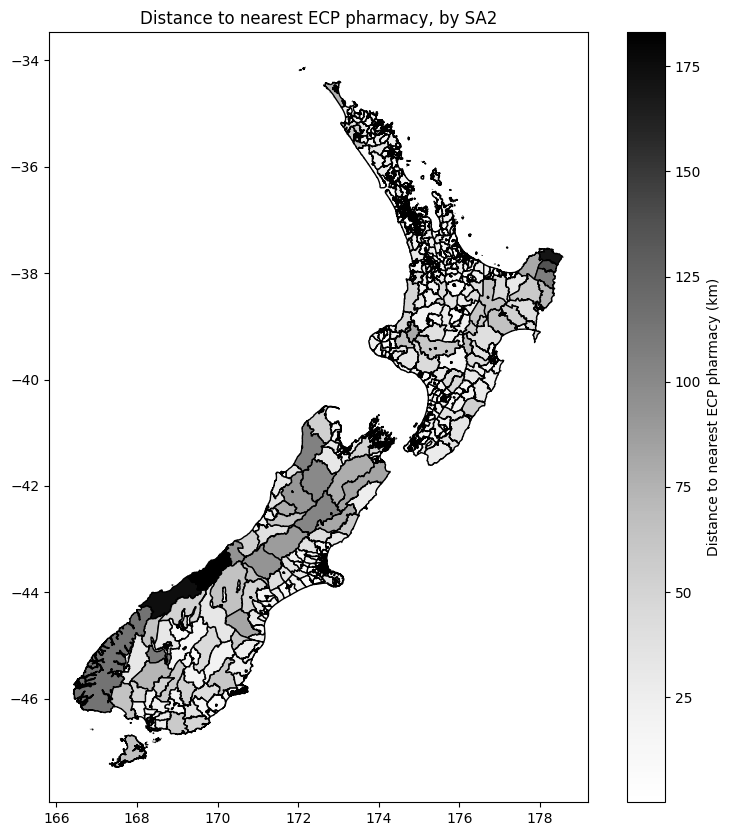

In [22]:
sa2["Distance to nearest ECP pharmacy (km)"] = sa2["Distance to nearest ECP pharmacy"] / 1000
ax = sa2.to_crs(4326).plot("Distance to nearest ECP pharmacy (km)", cmap="Grays", figsize=(10,10), legend=True, edgecolor="black", legend_kwds={"label": "Distance to nearest ECP pharmacy (km)"})
ax.title.set_text("Distance to nearest ECP pharmacy, by SA2")